# Imports

In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Model And Data Loading

In [ ]:
# model = joblib.load('../models/random_forest.pkl')
model = joblib.load('../models/best_model_v1.pkl')
# model = joblib.load('../models/best_model_v1.pkl')

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

# Metrics

In [3]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

ValueError: feature_names mismatch: ['age', 'height_cm', 'weight_kg', 'strength', 'reaction', 'stamina', 'speed', 'intelligence', 'perception', 'agility', 'endurance', 'stress_resistance', 'luck', 'panic', 'fatigue', 'hunger', 'thirst', 'mental_stability', 'focus', 'confidence', 'pain_tolerance', 'has_flashlight', 'flashlight_battery', 'has_knife', 'has_backpack', 'has_first_aid_kit', 'medkit_count', 'has_water', 'water_amount', 'has_food', 'food_amount', 'has_radio', 'level_difficulty', 'visibility', 'entity_density', 'entity_aggression', 'resource_density', 'maze_complexity', 'geometry_stability', 'spawn_area_danger', 'distance_to_nearest_entity', 'noise_generated', 'time_since_last_encounter', 'sex_male', 'sex_other', 'level_id_1', 'level_id_2', 'level_id_3', 'level_id_4', 'level_id_5', 'level_id_6', 'level_id_7', 'level_id_8', 'level_id_end', 'special_rule_darkness', 'special_rule_flooding', 'special_rule_haunted_hotel', 'special_rule_liminal_office', 'special_rule_mechanical_noise

In [ ]:
print(classification_report(y_test, pred))
print('ROC-AUC: ', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.51      0.64      0.56      1834
           1       0.75      0.64      0.69      3166

    accuracy                           0.64      5000
   macro avg       0.63      0.64      0.63      5000
weighted avg       0.66      0.64      0.64      5000

ROC-AUC:  0.6985428603117503


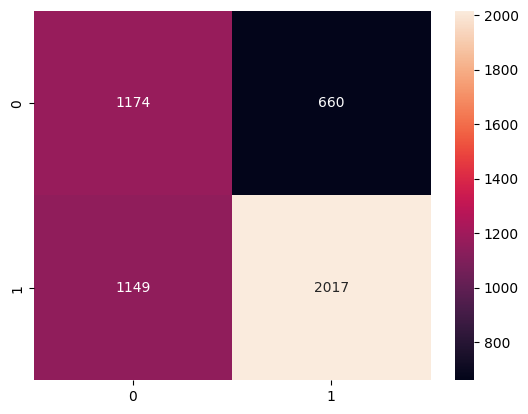

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
plt.show()

In [ ]:
confusion_matrix(y_test, pred)

array([[1174,  660],
       [1149, 2017]])

# Feature Importance

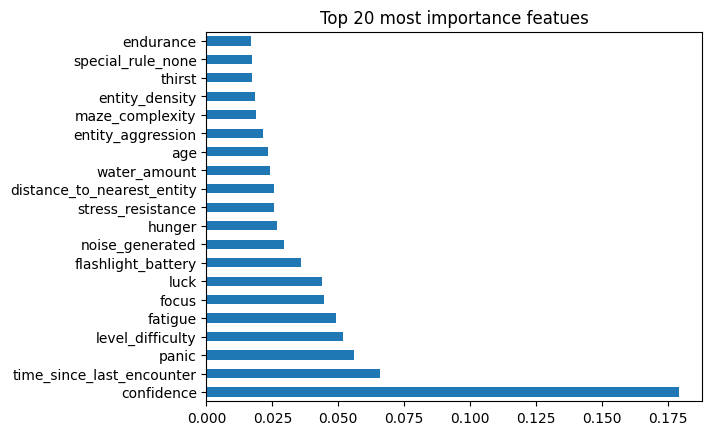

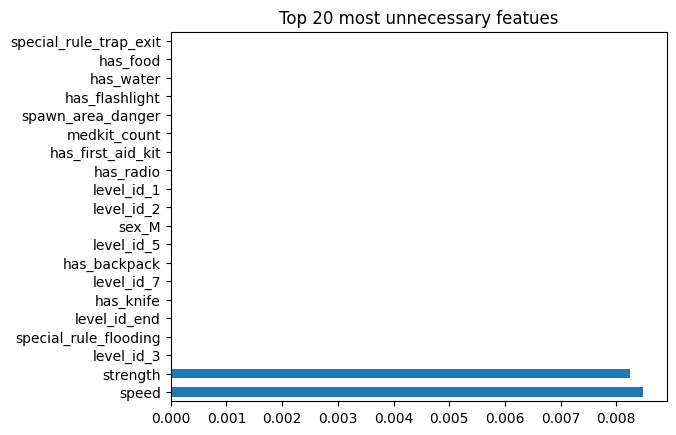

In [ ]:
importances = pd.Series(model.feature_importances_, index=X_test.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 most importance featues')
plt.show()
importances.sort_values(ascending=False).tail(20).plot(kind='barh')
plt.title('Top 20 most unnecessary featues')
plt.show()

In [ ]:
# df_temp = pd.read_csv('../data/raw/backrooms_survival_v4.csv')

# dataframe_for_pydantic = df_temp[['fatigue', 'panic', 'thirst', 'reaction', 'hunger', 'survived_24h']]
# dataframe_for_pydantic.to_csv('../data/processed/streamlit_test.csv', sep=',', index=False)

In [ ]:
# df_streamlit = pd.read_csv('../data/processed/streamlit_test.csv')
# df_streamlit.describe()